In [ ]:
import torch
from torch import nn

from helper import *

import torchvision

import matplotlib.pyplot as plt

plt.ion()

In [ ]:
# Normalize the images from [0, 1] to [-1, 1] and flatten them
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,)),
])

training_data = torchvision.datasets.MNIST(
    root="data", train=True, download=True, transform=transform)

test_data = torchvision.datasets.MNIST(
    root="data", train=False, download=True, transform=transform)



In [ ]:
class MLP(nn.Module):

  def __init__(self, input_dim, output_dim):
    super().__init__()

    ################################################
    # Use nn.Sequential() to build your network. Name the network "self.mlp = ...".
    self.mlp = nn.Sequential(
      nn.Flatten(),

      nn.Linear(input_dim, 128),
      nn.ReLU(),

      nn.Linear(128, 128),
      nn.ReLU(),

      nn.Linear(128, 64),
      nn.ReLU(),

      nn.Linear(64, output_dim),

      nn.Tanh()
    )

    ################################################

  def forward(self, imgs):
    '''
    Arguments:
      imgs torch.Tensor: images of shape (batch_size, 1, 28, 28).
    Returns:
      torch.Tensor: predictions of shape (batch_size, 10).
    '''
    ################################################
    Y = self.mlp(imgs)
    return Y

    ################################################

  def predict(self, imgs):
    '''
    Arguments:
      imgs torch.Tensor: images of shape (batch_size, 1, 28, 28).
    Returns:
      torch.Tensor: predicted class indices of shape (batch_size).
    '''
    Y = torch.argmax(self.forward(imgs), 1)
    return Y

In [ ]:
img_dim = 28 * 28

latent_dim = 100
lr = 2e-4
batch_size = 128
num_epochs = 50

training_loader = torch.utils.data.DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

discriminator = MLP(img_dim, 1)
generator = MLP(latent_dim, img_dim)

optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr)
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr)

In [13]:
def create_img_sample(img_array):
    print(img_array.shape)
    return torch.reshape(img_array, (28, 28))

In [ ]:
def train():
    for epoch in range(num_epochs):
        for real_imgs, _ in training_loader:
            
            real_labels = torch.ones((real_imgs.shape[0], 1))
            fake_labels = torch.zeros((real_imgs.shape[0], 1))

            ### Discriminator ####
            z = torch.randn(real_imgs.shape[0], latent_dim) # latent noise for all batch samples
            fake_imgs = generator(z) # create imgs from noise
            
            real_loss = nn.functional.binary_cross_entropy_with_logits(discriminator(real_imgs), real_labels)
            fake_loss = nn.functional.binary_cross_entropy_with_logits(discriminator(fake_imgs), fake_labels)
            d_loss = real_loss + fake_loss

            optimizer_D.zero_grad()

            d_loss.backward()

            optimizer_D.step()
            
            ### Generator ###
            z = torch.randn(real_imgs.shape[0], latent_dim)
            generated_imgs = nn.functional.tanh(generator(z))
            g_loss = nn.functional.binary_cross_entropy_with_logits(discriminator(generated_imgs), real_labels)

            optimizer_G.zero_grad()

            g_loss.backward()

            optimizer_G.step()

        img_sample = create_img_sample(nn.functional.tanh(generator(torch.randn(1, latent_dim))))
        plt.imshow(img_sample.detach().numpy(), cmap="gray")
        plt.pause(0.001)
            
        print(f"Epoch [{epoch+1}/{num_epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

torch.Size([1, 784])


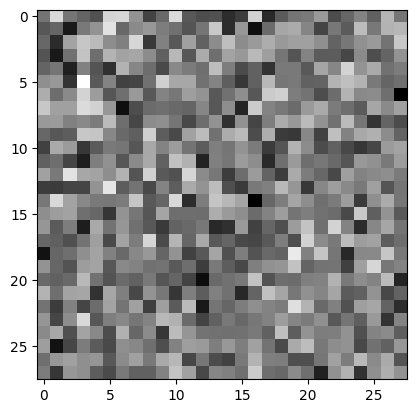

Epoch [1/50] | D Loss: 0.0074 | G Loss: 4.3601
torch.Size([1, 784])


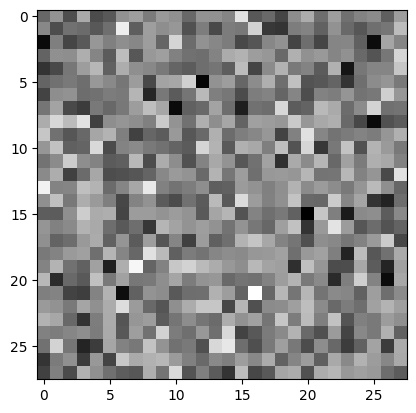

Epoch [2/50] | D Loss: 0.0003 | G Loss: 7.4509
torch.Size([1, 784])


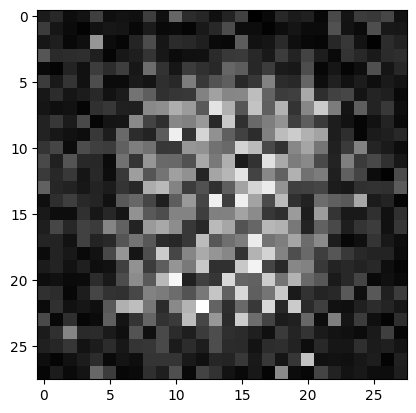

Epoch [3/50] | D Loss: 0.0088 | G Loss: 7.9297
torch.Size([1, 784])


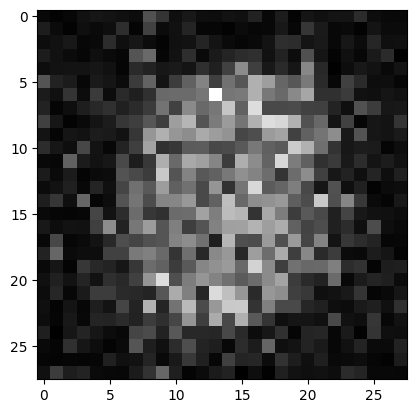

Epoch [4/50] | D Loss: 0.2027 | G Loss: 3.8750
torch.Size([1, 784])


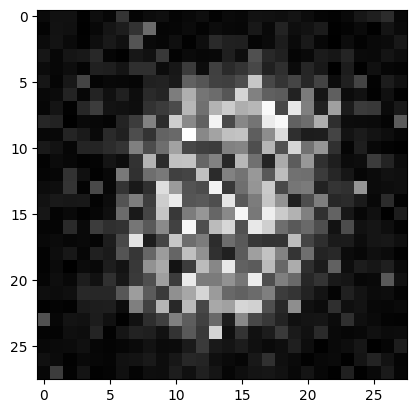

Epoch [5/50] | D Loss: 0.4464 | G Loss: 3.1817
torch.Size([1, 784])


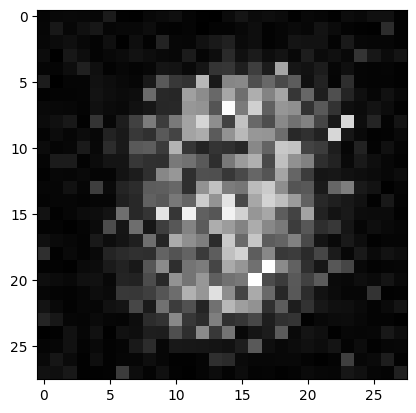

Epoch [6/50] | D Loss: 0.1579 | G Loss: 2.9841
torch.Size([1, 784])


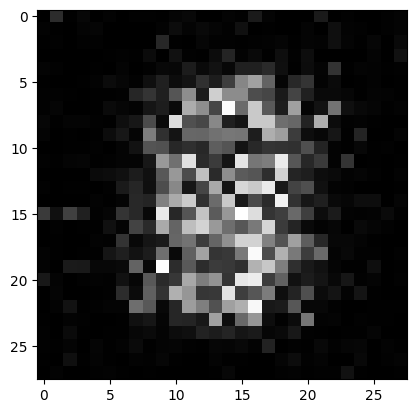

Epoch [7/50] | D Loss: 0.1228 | G Loss: 5.0224
torch.Size([1, 784])


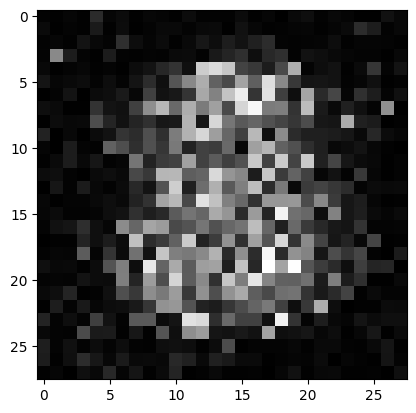

Epoch [8/50] | D Loss: 0.0324 | G Loss: 5.2576
torch.Size([1, 784])


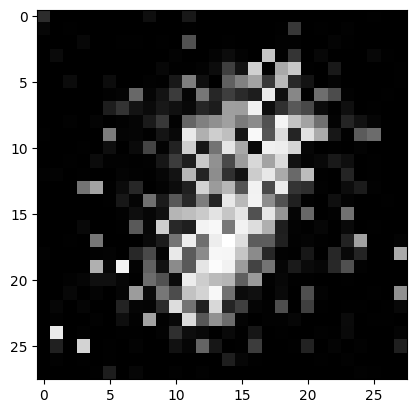

Epoch [9/50] | D Loss: 0.1281 | G Loss: 4.6519
torch.Size([1, 784])


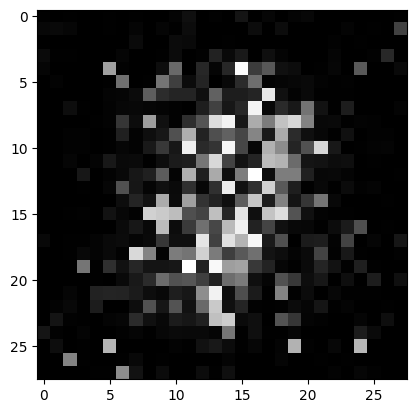

Epoch [10/50] | D Loss: 0.0171 | G Loss: 6.0620
torch.Size([1, 784])


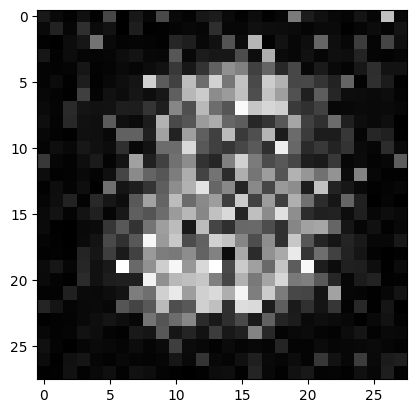

Epoch [11/50] | D Loss: 0.0571 | G Loss: 5.8556
torch.Size([1, 784])


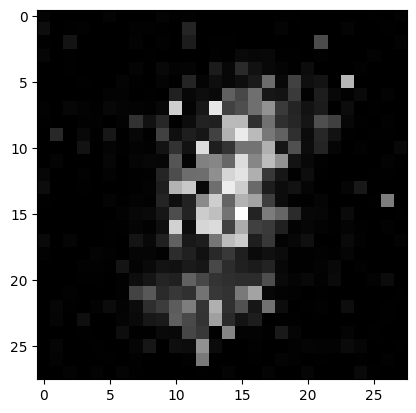

Epoch [12/50] | D Loss: 0.0735 | G Loss: 4.4683
torch.Size([1, 784])


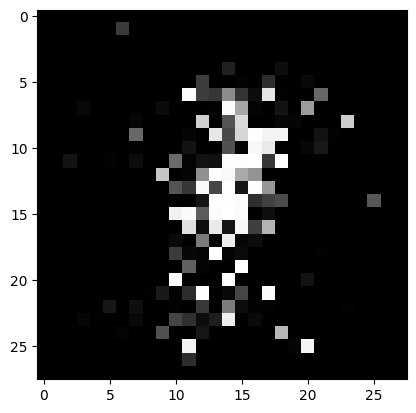

Epoch [13/50] | D Loss: 0.0415 | G Loss: 6.4955
torch.Size([1, 784])


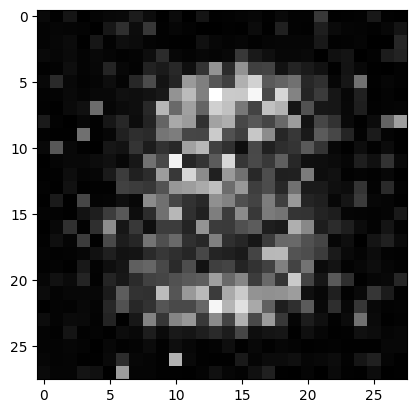

Epoch [14/50] | D Loss: 0.0264 | G Loss: 8.3360
torch.Size([1, 784])


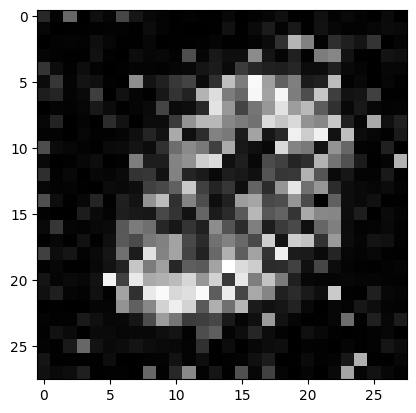

Epoch [15/50] | D Loss: 0.1019 | G Loss: 6.5360
torch.Size([1, 784])


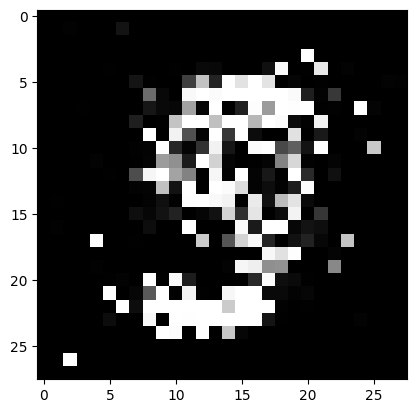

Epoch [16/50] | D Loss: 0.0081 | G Loss: 8.8450
torch.Size([1, 784])


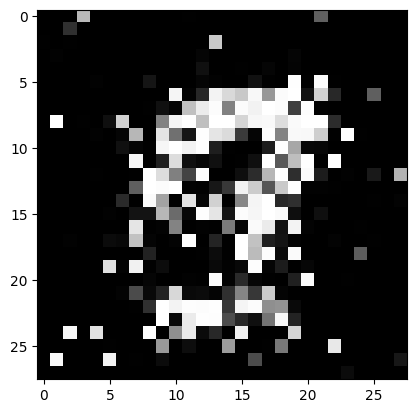

Epoch [17/50] | D Loss: 0.0475 | G Loss: 5.5860
torch.Size([1, 784])


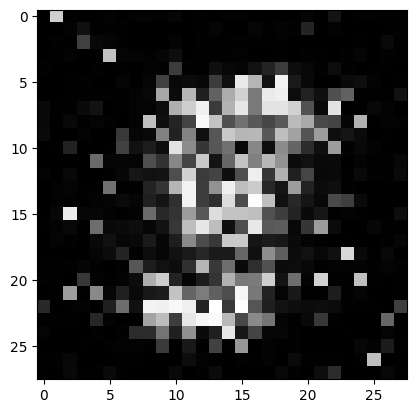

Epoch [18/50] | D Loss: 0.0299 | G Loss: 6.2194
torch.Size([1, 784])


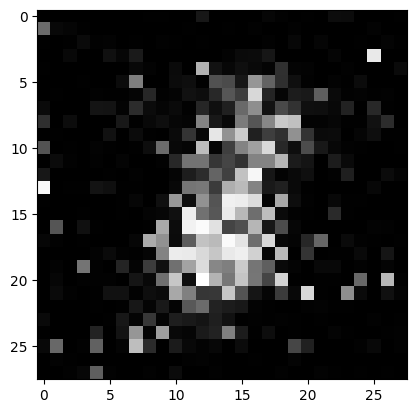

Epoch [19/50] | D Loss: 0.1896 | G Loss: 4.7297
torch.Size([1, 784])


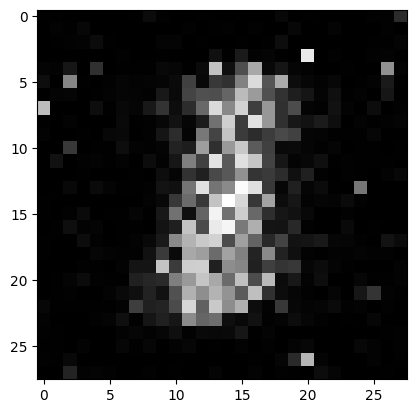

Epoch [20/50] | D Loss: 0.0033 | G Loss: 8.6166
torch.Size([1, 784])


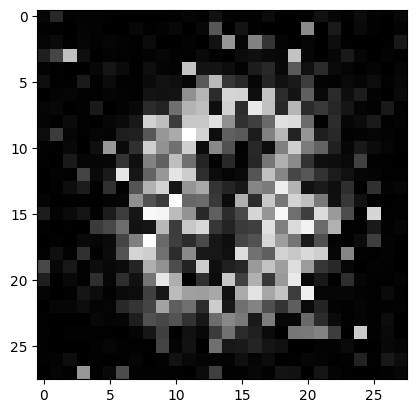

Epoch [21/50] | D Loss: 0.0295 | G Loss: 7.0155
torch.Size([1, 784])


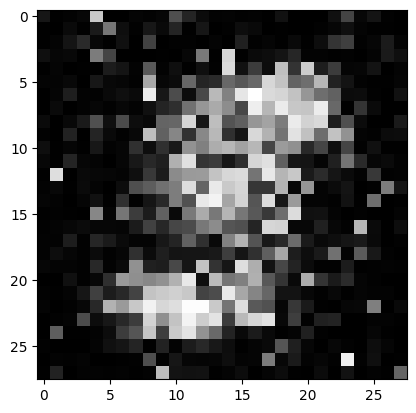

Epoch [22/50] | D Loss: 0.0095 | G Loss: 8.4757
torch.Size([1, 784])


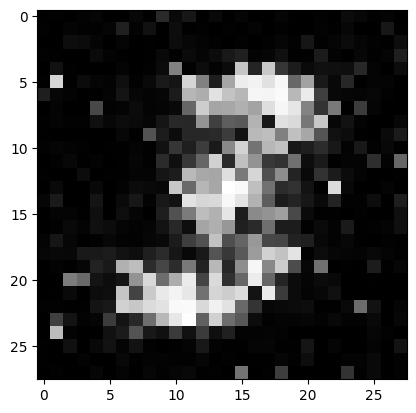

Epoch [23/50] | D Loss: 0.0023 | G Loss: 7.8071
torch.Size([1, 784])


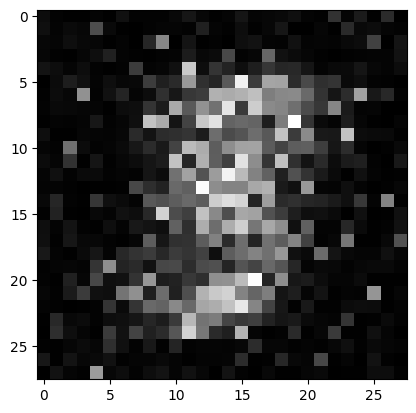

Epoch [24/50] | D Loss: 0.0067 | G Loss: 9.3436
torch.Size([1, 784])


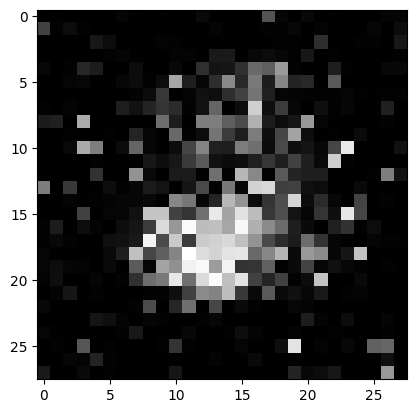

Epoch [25/50] | D Loss: 0.0192 | G Loss: 8.5225
torch.Size([1, 784])


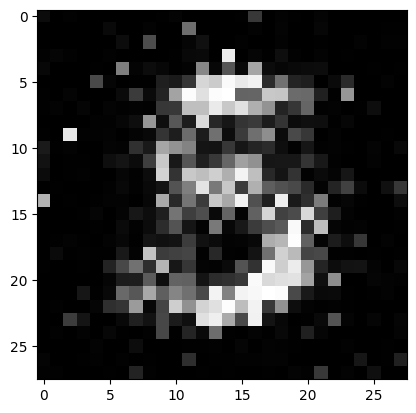

Epoch [26/50] | D Loss: 0.0721 | G Loss: 6.4987
torch.Size([1, 784])


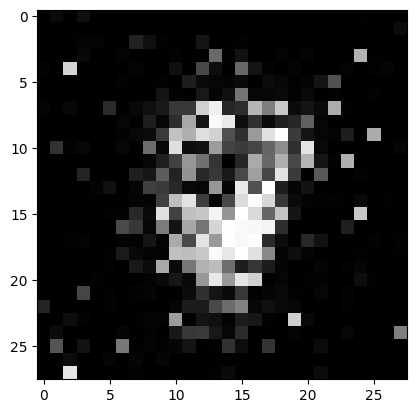

Epoch [27/50] | D Loss: 0.0642 | G Loss: 6.3868
torch.Size([1, 784])


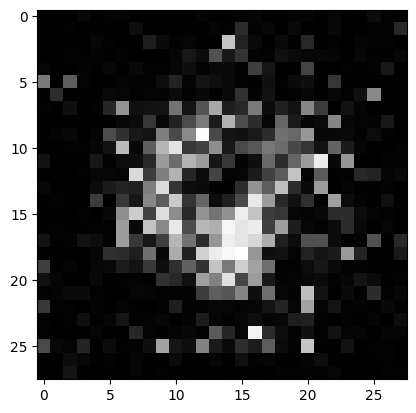

Epoch [28/50] | D Loss: 0.0921 | G Loss: 4.6188
torch.Size([1, 784])


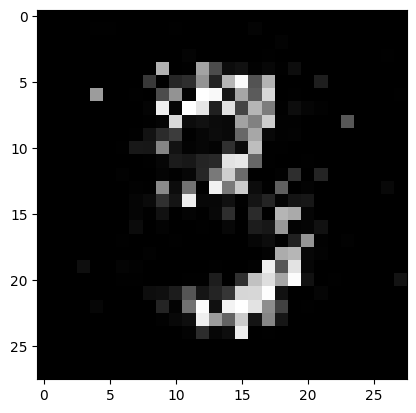

Epoch [29/50] | D Loss: 0.1174 | G Loss: 6.8107
torch.Size([1, 784])


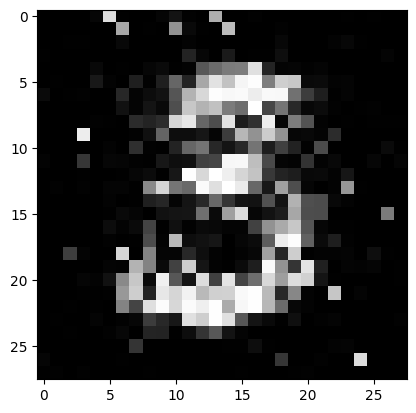

Epoch [30/50] | D Loss: 0.0741 | G Loss: 6.4950
torch.Size([1, 784])


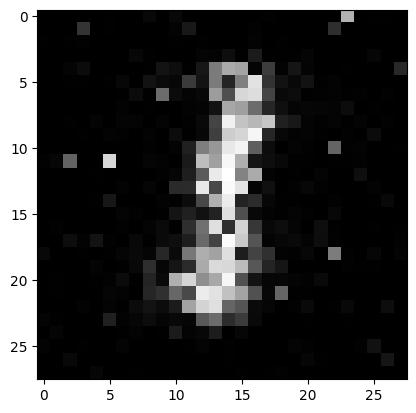

Epoch [31/50] | D Loss: 0.0787 | G Loss: 4.6079
torch.Size([1, 784])


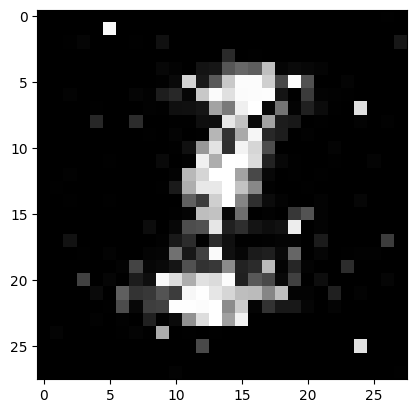

Epoch [32/50] | D Loss: 0.0894 | G Loss: 5.4886
torch.Size([1, 784])


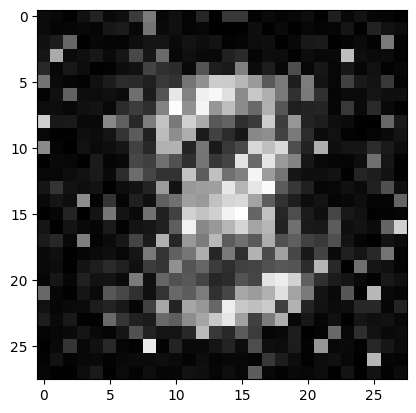

Epoch [33/50] | D Loss: 0.0391 | G Loss: 8.4623
torch.Size([1, 784])


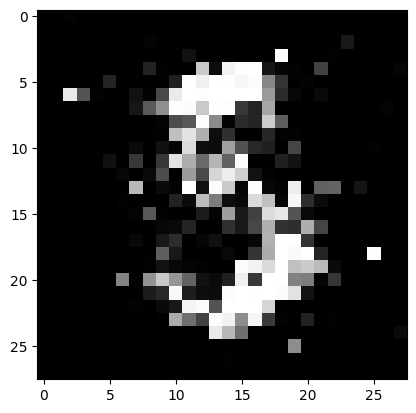

Epoch [34/50] | D Loss: 0.0668 | G Loss: 5.1603
torch.Size([1, 784])


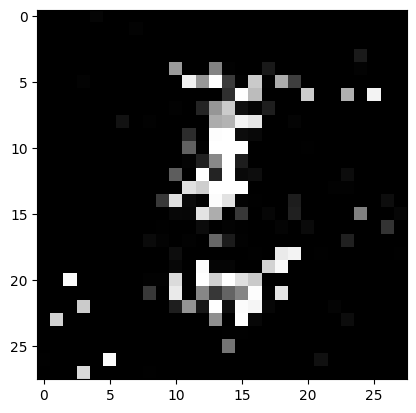

Epoch [35/50] | D Loss: 0.0979 | G Loss: 4.8873
torch.Size([1, 784])


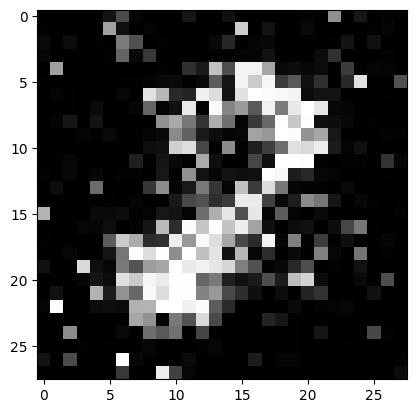

Epoch [36/50] | D Loss: 0.0472 | G Loss: 6.2862
torch.Size([1, 784])


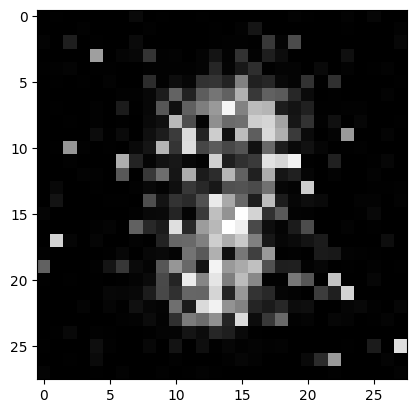

Epoch [37/50] | D Loss: 0.0465 | G Loss: 7.0130
torch.Size([1, 784])


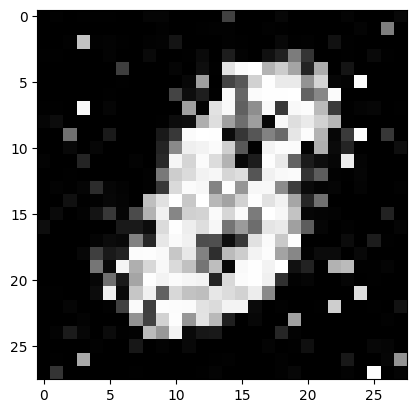

Epoch [38/50] | D Loss: 0.0967 | G Loss: 4.3950
torch.Size([1, 784])


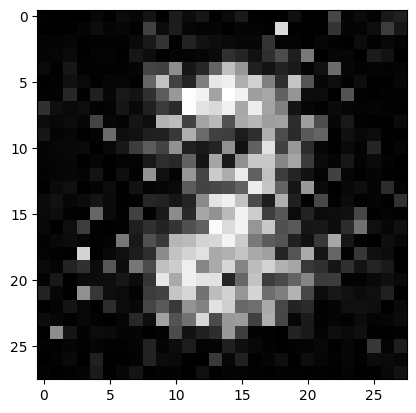

Epoch [39/50] | D Loss: 0.0673 | G Loss: 8.7555
torch.Size([1, 784])


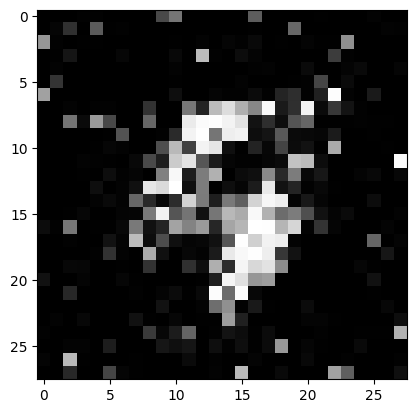

Epoch [40/50] | D Loss: 0.1061 | G Loss: 6.6432
torch.Size([1, 784])


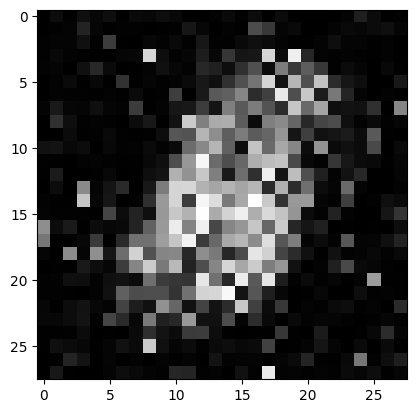

Epoch [41/50] | D Loss: 0.0530 | G Loss: 4.5420
torch.Size([1, 784])


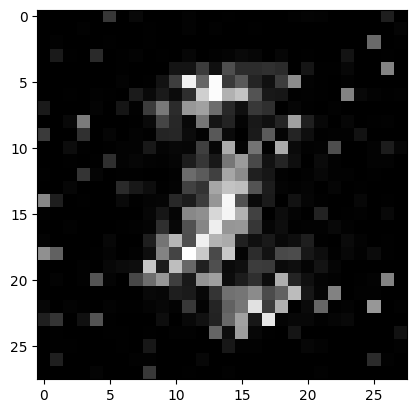

Epoch [42/50] | D Loss: 0.0440 | G Loss: 6.5832
torch.Size([1, 784])


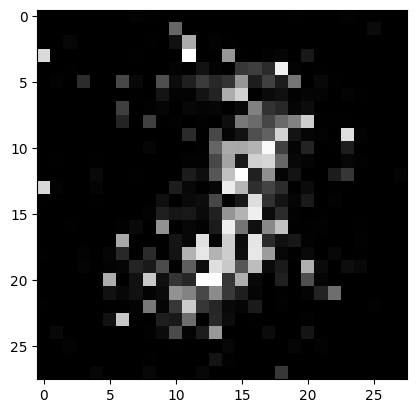

Epoch [43/50] | D Loss: 0.0863 | G Loss: 5.1855
torch.Size([1, 784])


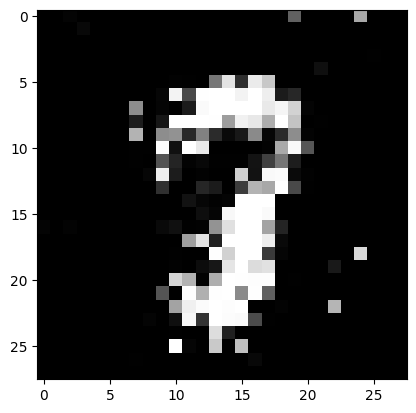

Epoch [44/50] | D Loss: 0.1336 | G Loss: 4.2574
torch.Size([1, 784])


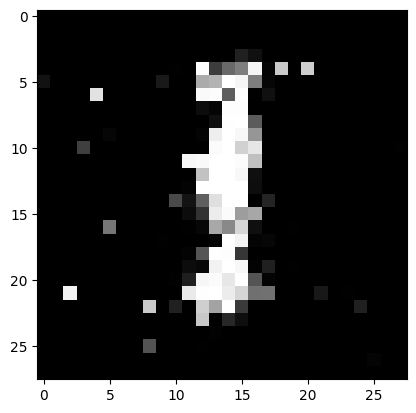

Epoch [45/50] | D Loss: 0.0592 | G Loss: 5.7682
torch.Size([1, 784])


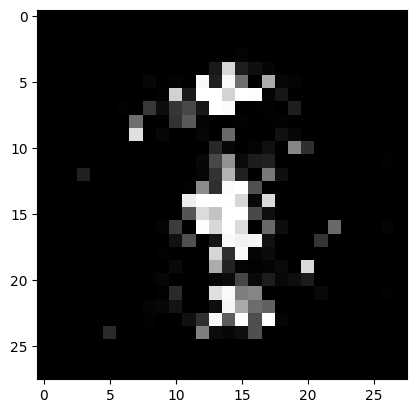

Epoch [46/50] | D Loss: 0.0782 | G Loss: 5.8632
torch.Size([1, 784])


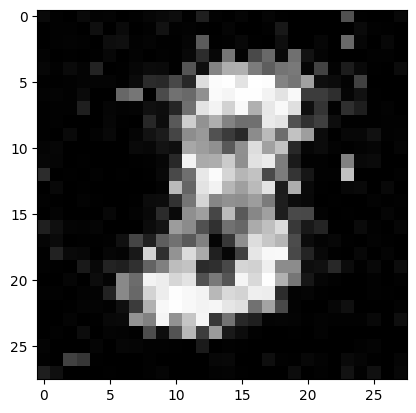

Epoch [47/50] | D Loss: 0.1843 | G Loss: 4.9065
torch.Size([1, 784])


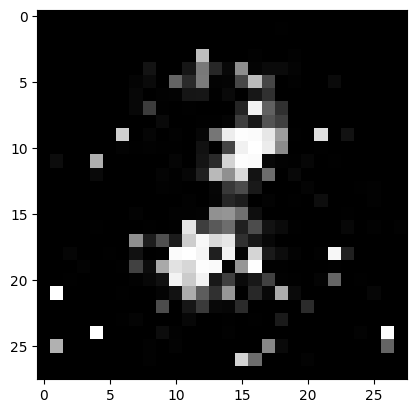

Epoch [48/50] | D Loss: 0.1030 | G Loss: 4.4648
torch.Size([1, 784])


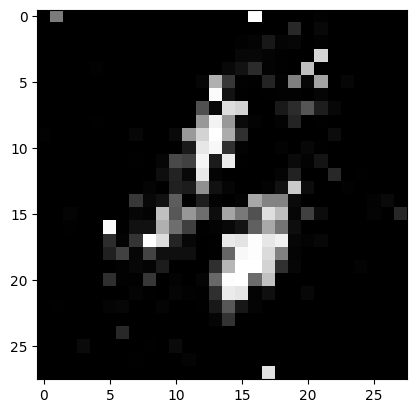

Epoch [49/50] | D Loss: 0.1394 | G Loss: 4.2495
torch.Size([1, 784])


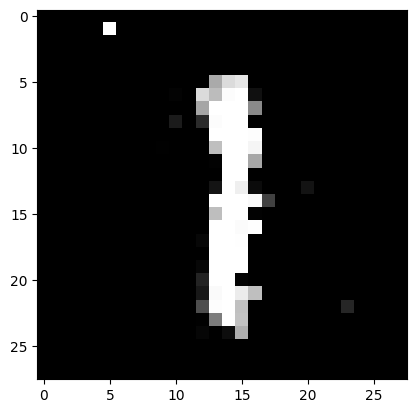

Epoch [50/50] | D Loss: 0.1490 | G Loss: 3.9662


In [15]:
train()